# A module of two TESLA cavities

In this tutorial we solve the TESLA 9-cell cavity once with a beam on its axis, reduce
it, and build a module of two cavities from two copies of the reduced cavity. We
compute the module's beam impedance from 1.0 to 2.9 GHz at 1 MHz spacing and check it
against the two cavities solved in one piece.

**Prerequisites:** [Beam impedance of the TESLA cavity](tesla_beam_impedance.ipynb) and
[Join parts with a beam](beam_through_parts.ipynb). The notebook runs in about
eight minutes.

## 1. Solve and reduce one cavity

### 1.1 Build the cavity with a beam

The cavity of [the TESLA tutorial](tesla_beam_impedance.ipynb), in a project of its own,
with the beam on its axis.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from cavsim3d.core.em_project import EMProject

tesla_mid = [42, 42, 12, 19, 35, 57.7, 103.353]        # A, B, a, b, Ri, L, Req [mm]
tesla_end_left = [40.34, 40.34, 10, 13.5, 39, 55.716, 103.353]
tesla_end_right = [42, 42, 9, 12.8, 39, 56.815, 103.353]
tesla = dict(n_cells=9, mid_cell=tesla_mid, end_cell_left=tesla_end_left,
             end_cell_right=tesla_end_right, beampipe="both")

cavity = EMProject(name="tesla_cavity", base_dir="./simulations", overwrite=True)
cavity.create_primitive("elliptical_cavity", name="tesla", **tesla)
cavity.add_beam("beam")
mesh = cavity.generate_mesh(maxh=0.025, curvaturesafety=0.5)
print(f"{mesh.ne} elements")

✅ Creating new project 'tesla_cavity' at simulations\tesla_cavity


6291 elements


### 1.2 Sweep with field snapshots

A reduced model is built from field solutions, which `solve()` keeps by default. The
beam's phase runs along the 1.27 m cavity and repeats every $c/L$ = 237 MHz, so the
samples must lie closer than half of that: we take 39 samples, 50 MHz apart.

In [2]:
cfg = dict(fmin=1.0, fmax=2.9, nsamples=39, nportmodes=3, order=3)
t0 = time.time()
res = cavity.fds.solve(**cfg)
print(f"solved in {time.time() - t0:.0f} s")


Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 6291



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_11 (cos), kc=47.2097, sigma=+1


	port1 mode 1: TE_11 (sin), kc=47.2097, sigma=+1


	port1 mode 2: TM_01, kc=61.6620, sigma=+1
	port2 mode 0: TE_11 (cos), kc=47.2097, sigma=+1
	port2 mode 1: TE_11 (sin), kc=47.2097, sigma=+1
	port2 mode 2: TM_01, kc=61.6620, sigma=+1
Port eigenmodes complete: 6 total modes



FDS Solve: 1.0000 - 2.9000 GHz, 39 samples


Global Coupled Solve


  Auto solver: 132720 unknowns, a factorisation needs about 0.8 GB of 23.2 GB free -> 'direct'


  
Coupled solve complete: 2 external ports in 75.33s


solved in 77 s


Besides the field solutions, the solve stores the beam's data at the frequencies where a
reduced model interpolates the beam's phase.

### 1.3 Reduce the cavity

In [3]:
rom = cavity.fds.fom.reduce(tol=1e-8)
print(f"{rom.total_dofs} unknowns -> {rom.reduced_dimensions['global']}")

Model Order Reduction


Reduction complete: 132720 -> 205 DOFs (99.8% compression)


132720 unknowns -> 205


One basis of 205 vectors serves the six port modes and the beam. The reduced model is
saved in the project, ready to be imported.

## 2. Join two copies

### 2.1 Import the cavity twice

`n=2` repeats the imported cavity. The second copy sits with its first port on the
first copy's second port: 2.53 m of module, with 231 mm of beam pipe between the two
cavities.

In [4]:
module = EMProject(name="tesla_module", base_dir="./simulations", overwrite=True)
module.import_project("./simulations/tesla_cavity", name="tesla", n=2)
module.add_beam("beam")
print(module.geometry.describe_layout())

✅ Creating new project 'tesla_module' at simulations\tesla_module


Main axis: Z (default). Parts follow the list order along +Z:
  1. tesla x2: imported project
Mesh strategy: coupled (each unique part meshed and solved on its own, joined through port modes; imported: tesla; repeated: tesla (n=2))


### 2.2 Take the cavity's results

With the same request, the solve plan reuses the cavity's results: nothing is computed.

In [5]:
res = module.fds.solve(**cfg)

✅ Mesh strategy: coupled (imported: tesla; repeated: tesla (n=2)): each unique part is solved on its own and the parts are joined through their port modes.


✅ Solve plan:
  tesla  imported (reference) reuse     its reduced model fits the request; its beam results are there


✅ Netlist FOM stage complete: 1 unique section(s) for 2 instance(s) with the beam: join them with fds.foms.concatenate()


### 2.3 Reduce and join

In [6]:
concat = module.fds.foms.reduce(tol=1e-8).concatenate()
t0 = time.time()
res = concat.solve(fmin=1.0, fmax=2.9, nsamples=1901)
print(f"1901 frequencies in {time.time() - t0:.1f} s")
print("S~ columns:", concat.tilde_labels[1])

Reduced models reused: tesla



Concat Solve: 1.0000 - 2.9000 GHz, 1901 samples, system size 407


  Concat solve complete: 2.420s (1901 frequencies)


  Beam: the sections' generalised scattering matrices joined (4.558s)


1901 frequencies in 7.5 s
S~ columns: ['1(1)', '1(2)', '1(3)', '2(1)', '2(2)', '2(3)', 'b(1)']


`foms.reduce()` takes the cavity's reduced model as it is, read in place. `concatenate()`
couples the two copies through their port modes; at every frequency of
`concat.solve()` it also joins their generalised scattering matrices: the waves leaving
one copy enter the other, and the second copy sees the beam later, with the phase of its
position. The module keeps the six port modes at its two ends and the beam.

### 2.4 Plot the module's beam impedance


ROM Solve: 1.0000 - 2.9000 GHz, 1901 samples


  Solve loop: 0.136s (1901 freq points)


  Beam columns: 3.694s


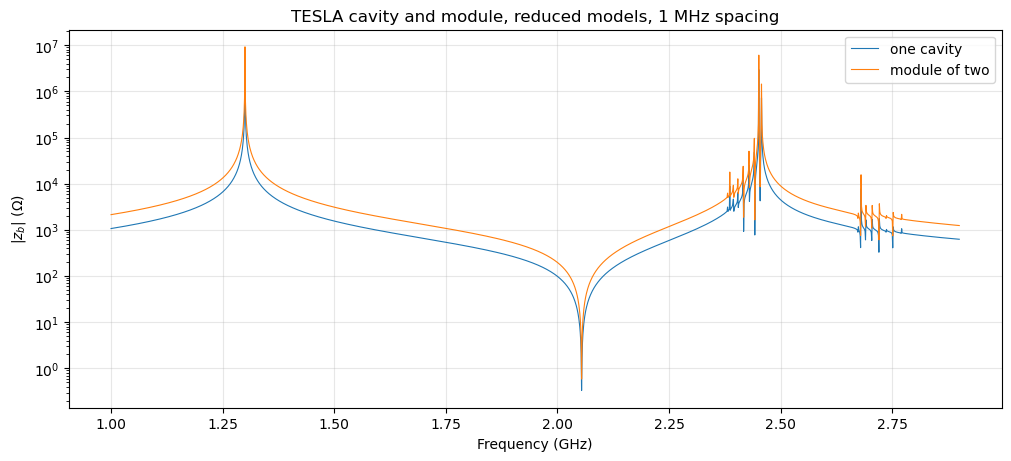

In [7]:
f = concat.frequencies
zb_module = concat.s_tilde_dict["b(1)b(1)"]
rom.solve(fmin=1.0, fmax=2.9, nsamples=1901)
zb_cavity = rom.s_tilde_dict["b(1)b(1)"]

fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
ax.semilogy(f / 1e9, np.abs(zb_cavity), lw=0.8, label="one cavity")
ax.semilogy(f / 1e9, np.abs(zb_module), lw=0.8, label="module of two")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel(r"$|z_b|$ ($\Omega$)")
ax.set_title("TESLA cavity and module, reduced models, 1 MHz spacing")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

Away from the resonances the module's impedance is twice the cavity's: below the
cut-off the fields of one cavity hardly reach the other through the pipe between them,
and the beam voltages of the two add. Near 2.4 and 2.7 GHz the module shows more poles
than the cavity: there the modes of the two cavities couple through the pipe and split.

### 2.5 Check the join at the cavity's samples

At the 39 frequencies of the cavity's sweep, the two copies can also be joined at full
order, from the cavity's full-order $\tilde{S}$. The difference to the reduced join is
the reduction alone.

In [8]:
fom_join = module.fds.foms.concatenate()
concat.solve(fmin=1.0, fmax=2.9, nsamples=39)
z_fom, z_rom = fom_join.beam_impedance(), concat.beam_impedance()
rel = np.abs(z_rom - z_fom) / np.abs(z_fom)
print(f"reduced vs full-order join: median {np.median(rel):.1e}, largest {rel.max():.1e}")

✅ Joined 2 part copies through their generalised scattering matrices (beam): 6 external port mode(s), 39 frequencies (those of the full-order solve).



Concat Solve: 1.0000 - 2.9000 GHz, 39 samples, system size 407


  Concat solve complete: 0.201s (39 frequencies)


  Beam: the sections' generalised scattering matrices joined (0.097s)


reduced vs full-order join: median 7.1e-08, largest 1.5e-05


The two joins agree to a median of $7\cdot10^{-8}$, at most $1.5\cdot10^{-5}$: the
reduced cavity adds next to nothing to the join. The full-order join holds these 39
frequencies only, the reduced one any frequency of the band.

## 3. Check against the module in one piece

### 3.1 Solve the two cavities as one mesh

Two cavities, each added once, are glued into one mesh: the module solved without any
join. `per_domain=False` solves it in one piece, at 96 frequencies 20 MHz apart.

In [9]:
whole = EMProject(name="tesla_module_whole", base_dir="./simulations", overwrite=True)
for name in ("cav1", "cav2"):
    whole.create_primitive("elliptical_cavity", name=name, **tesla)
whole.add_beam("beam")
whole.generate_mesh(maxh=0.025, curvaturesafety=0.5)
t0 = time.time()
res = whole.fds.solve(fmin=1.0, fmax=2.9, nsamples=96, nportmodes=3, order=3,
                      per_domain=False, store_snapshots=False)
print(f"solved in {time.time() - t0:.0f} s")

✅ Creating new project 'tesla_module_whole' at simulations\tesla_module_whole


Main axis: Z (default). Parts follow the list order along +Z:
  1. cav1: z = [-0.6333, 0.6333] m
  2. cav2: z = [0.6333, 1.9] m
Mesh strategy: glued (one conformal mesh of all parts; all parts are geometry, each used once)



Assembly domain-material mapping:


  cav1: ['cav1/vacuum']
  cav2: ['cav2/vacuum']
Port naming complete:
  Total ports: 3
  External ports: 2
  Interface ports: 1



Structure Topology
  Type: Compound structure
  Domains (2): ['cav1', 'cav2']
  Ports (3): ['port1', 'port2', 'port3']
  Mesh elements: 12064
  External Ports (2): ['port1', 'port3']
  Internal Ports (1): ['port2']

  Domain-Port Mapping:
    cav1: ['port1 (input)', 'port2 (internal)']
    cav2: ['port2 (internal)', 'port3 (output)']



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_11 (cos), kc=47.2097, sigma=+1
	port1 mode 1: TE_11 (sin), kc=47.2097, sigma=+1
	port1 mode 2: TM_01, kc=61.6620, sigma=+1
	port2 mode 0: TE_11 (cos), kc=47.2097, sigma=+1
	port2 mode 1: TE_11 (sin), kc=47.2097, sigma=+1
	port2 mode 2: TM_01, kc=61.6620, sigma=+1


	port3 mode 0: TE_11 (cos), kc=47.2097, sigma=+1
	port3 mode 1: TE_11 (sin), kc=47.2097, sigma=+1
	port3 mode 2: TM_01, kc=61.6620, sigma=+1
Port eigenmodes complete: 9 total modes



FDS Solve: 1.0000 - 2.9000 GHz, 96 samples


Global Coupled Solve


  Auto solver: 255213 unknowns, a factorisation needs about 2.1 GB of 20.5 GB free -> 'direct'


  
Coupled solve complete: 2 external ports in 241.70s


solved in 244 s


### 3.2 Compare the beam impedance

We solve the joined model at the same 96 frequencies and plot both.


Concat Solve: 1.0000 - 2.9000 GHz, 96 samples, system size 407


  Concat solve complete: 0.278s (96 frequencies)


  Beam: the sections' generalised scattering matrices joined (0.233s)


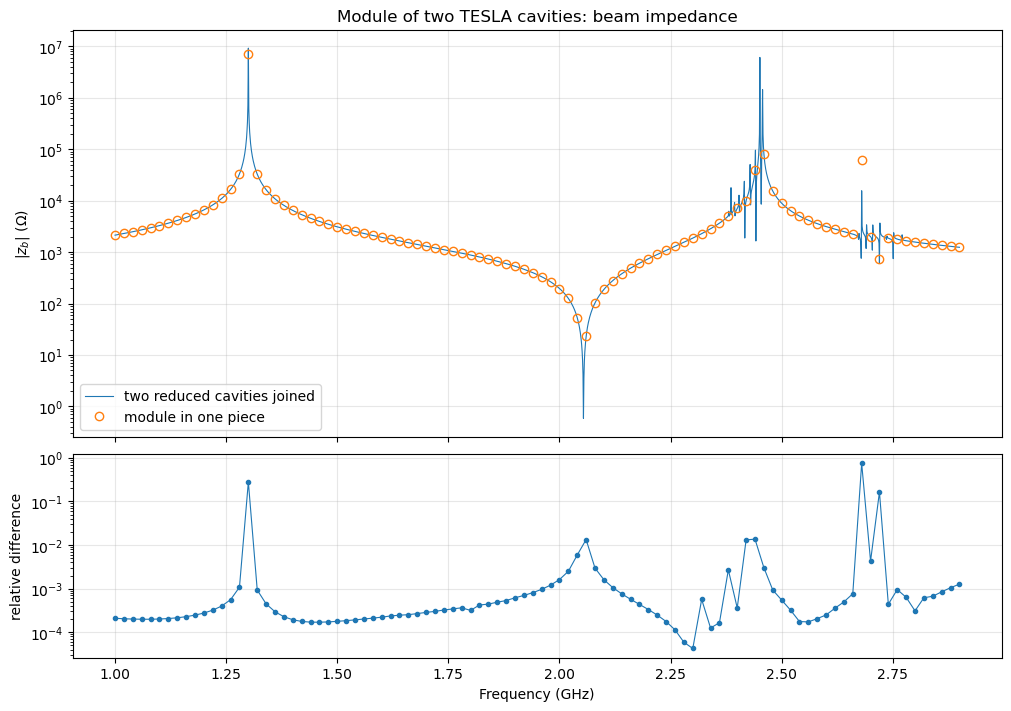

relative difference: median 3.5e-04, largest 7.5e-01 at 2.680 GHz


In [10]:
f_whole = whole.fds.fom.frequencies
zb_whole = whole.fds.fom.s_tilde_dict["b(1)b(1)"]
concat.solve(fmin=1.0, fmax=2.9, nsamples=96)
zb_joined = concat.s_tilde_dict["b(1)b(1)"]

fig, (ax, ax_err) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, layout="constrained",
                                 height_ratios=[2, 1])
ax.semilogy(f / 1e9, np.abs(zb_module), lw=0.8, label="two reduced cavities joined")
ax.semilogy(f_whole / 1e9, np.abs(zb_whole), lw=0, marker="o", mfc="none",
            label="module in one piece")
ax.set_ylabel(r"$|z_b|$ ($\Omega$)")
ax.set_title("Module of two TESLA cavities: beam impedance")
ax.grid(True, alpha=0.3)
ax.legend()
rel = np.abs(zb_joined - zb_whole) / np.abs(zb_whole)
ax_err.semilogy(f_whole / 1e9, rel, marker="o", ms=3, lw=0.8)
ax_err.set_ylabel("relative difference")
ax_err.set_xlabel("Frequency (GHz)")
ax_err.grid(True, alpha=0.3)
plt.show()
print(f"relative difference: median {np.median(rel):.1e}, largest {rel.max():.1e} "
      f"at {f_whole[np.argmax(rel)] / 1e9:.3f} GHz")

Away from the resonances the joined model and the module in one piece agree within
$10^{-3}$ (median $3.5\cdot10^{-4}$); the bump near 2.06 GHz is where $|z_b|$ falls to a
few ohms. The large differences sit at samples right next to a resonance: 0.28 at
1.30 GHz, 0.75 at 2.68 GHz and 0.17 at 2.72 GHz. There a small shift of the resonance
between the two models changes $|z_b|$ a lot.

### 3.3 Compare the resonances

The poles of the beam impedance with open ports are the resonances. We compute the
50 resonances of the one-piece module from 1.25 GHz up and pair each with the nearest
resonance of the joined model.

In [11]:
t0 = time.time()
f_res_whole = whole.fds.fom.get_resonant_frequencies(n_modes=50, fmin=1.25)
print(f"eigenmodes in {time.time() - t0:.0f} s, "
      f"{f_res_whole.min() / 1e9:.3f} to {f_res_whole.max() / 1e9:.3f} GHz")
f_res_joined = concat.get_resonant_frequencies(fmin=1.0, fmax=2.9)
nearest = np.array([f_res_joined[np.argmin(np.abs(f_res_joined - fr))] for fr in f_res_whole])
shift = np.abs(nearest / f_res_whole - 1)
print(f"relative shift: median {np.median(shift):.1e}, largest {shift.max():.1e}")

eigenmodes in 94 s, 1.276 to 1.762 GHz
relative shift: median 2.0e-05, largest 1.1e-04


The 50 resonances from 1.28 to 1.76 GHz, the accelerating passband among them, lie
within a median $2\cdot10^{-5}$ of the joined model's, at most $1.1\cdot10^{-4}$. That is
the difference between the two meshes: the module in one piece is meshed as a whole,
the joined model is made from two copies of the cavity's mesh. At 1.3 GHz,
$2\cdot10^{-5}$ moves a pole by 26 kHz, against 70 kHz between the π-mode and the
sample at 1.300 GHz: enough for the 28 % difference there.

## What we did

We solved the TESLA cavity once with a beam and field snapshots, reduced it, imported it
twice into a module and joined the reduced copies with the beam. The joined model gave
the module's beam impedance at 1901 frequencies in seconds. It matches the full-order
join of the same copies, and the two cavities solved in one piece up to the
discretisation of the two meshes.

**Next:** [Applications](../applications/index.md).

**Background:** [Model order reduction with the beam](../../theory/beam_reduction.md),
§10.7 for joining reduced parts.